# Treinamento - Rede Neural

## Objetivo

Treinar um modelo de Rede Neural para prever a probabilidade de abandono do tratamento de tuberculose (LTFU).

## Estratégia de Avaliação

- **Rodada 1:** treino -> teste1 (validação interna)
- **Rodada 2:** treino + teste1 -> teste2 (validação externa)

## Métricas Utilizadas

- Recall
- Precisão
- F1-score
- Acurácia
- ROC-AUC

**Recall** foi considerado a principal métrica do projeto, pois o objetivo é identificar o maior número possível de pacientes com risco de abandono.

## Tratamento do Desbalanceamento

- Class Weights
- Sample Weights para pacientes reingressos após abandono

## Explicabilidade

Foi utilizada a técnica **Permutation Importance** para identificar as variáveis mais importantes para as previsões do modelo.

In [99]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers, regularizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, recall_score, classification_report, precision_score,
    roc_auc_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
#Carregar os dados

BASE = '/content/drive/MyDrive/'

X_train = pd.read_csv(BASE + 'X_train_proc.csv')
X_test1 = pd.read_csv(BASE + 'X_test1_proc.csv')
X_test2 = pd.read_csv(BASE + 'X_test2_proc.csv')

y_train = pd.read_csv(BASE + 'y_train.csv').squeeze()
y_test1 = pd.read_csv(BASE + 'y_test1.csv').squeeze()
y_test2 = pd.read_csv(BASE + 'y_test2.csv').squeeze()

X_train2 = pd.concat([X_train, X_test1], ignore_index=True)
y_train2 = pd.concat([y_train, y_test1], ignore_index=True)

X_train_np = X_train.values.astype('float32')
X_test1_np = X_test1.values.astype('float32')
X_test2_np = X_test2.values.astype('float32')
X_train2_np = X_train2.values.astype('float32')

y_train_np = y_train.values.astype('int32')
y_test1_np = y_test1.values.astype('int32')
y_test2_np = y_test2.values.astype('int32')
y_train2_np = y_train2.values.astype('int32')

print(f'X_train : {X_train_np.shape}')
print(f'X_test1 : {X_test1_np.shape}')
print(f'X_train2: {X_train2_np.shape}')
print(f'X_test2 : {X_test2_np.shape}')

print(
    f'\nTaxa abandono - treino: {y_train_np.mean()*100:.1f}% | '
    f'teste1: {y_test1_np.mean()*100:.1f}% | '
    f'teste2: {y_test2_np.mean()*100:.1f}%'
)

X_train : (562632, 25)
X_test1 : (631, 25)
X_train2: (563263, 25)
X_test2 : (631, 25)

Taxa abandono - treino: 19.4% | teste1: 43.9% | teste2: 69.4%


In [101]:
# Class weights

pesos = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
pesos_dict = dict(enumerate(pesos))
print(f'Class weights: {pesos_dict}')

# Sample weights: reingressos com peso 3x
# TRATAMENTO=3 (reingresso) após OrdinalEncoder vira índice 2.0
col_trat = X_train.columns.get_loc('TRATAMENTO')

def calcular_sample_weight(X_np, y_np, pesos_dict, col_trat, peso_reing=3.0):
    sw = np.where(y_np == 1, pesos_dict[1], pesos_dict[0]).astype('float32')
    mask_reing = (X_np[:, col_trat] == 2.0)
    sw[mask_reing] *= peso_reing
    n_reing = mask_reing.sum()
    print(f'  Reingressos: {n_reing} ({n_reing/len(X_np)*100:.1f}%) com peso {peso_reing}x extra')
    return sw

print('\nSample weights - Rodada 1:')
sw_train = calcular_sample_weight(X_train_np, y_train_np, pesos_dict, col_trat)

pesos2 = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train2_np),
    y=y_train2_np
)

pesos2_dict = dict(enumerate(pesos2))

print('Sample weights - Rodada 2:')
col_trat2 = X_train2.columns.get_loc('TRATAMENTO')
sw_train2 = calcular_sample_weight(X_train2_np, y_train2_np, pesos2_dict, col_trat2)

Class weights: {0: np.float64(0.6204888635972632), 1: np.float64(2.574880553572409)}

Sample weights - Rodada 1:
  Reingressos: 58090 (10.3%) com peso 3.0x extra
Sample weights - Rodada 2:
  Reingressos: 58319 (10.4%) com peso 3.0x extra


In [102]:
# Função de Avaliação

def avaliar(nome, y_true, y_pred, y_prob):
    print(f'\n{nome}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Não abandona (0)', 'Abandona (1)']))
    auc = roc_auc_score(y_true, y_prob)
    print(f'ROC-AUC: {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0],
        display_labels=['Não abandona', 'Abandona'],
        colorbar=False
    )
    axes[0].set_title(f'Matriz de Confusão - {nome}')
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
    axes[1].set_title(f'Curva ROC - {nome} (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'--', color='gray')
    plt.tight_layout()
    plt.savefig(
    f'/content/drive/MyDrive/graficos/{nome}.png',
    dpi=300,
    bbox_inches='tight'
)

    plt.show()
    return auc

def plotar_curvas(historico, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(historico.history['loss'], label='treino')
    axes[0].plot(historico.history['val_loss'], label='validação')
    axes[0].set_title(f'Loss - {titulo}')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(historico.history['auc'], label='treino')
    axes[1].plot(historico.history['val_auc'], label='validação')
    axes[1].set_title(f'AUC - {titulo}')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(
    f'/content/drive/MyDrive/graficos/{titulo}.png',
    dpi=300,
    bbox_inches='tight'
)
    plt.show()
    melhor = max(historico.history['val_auc'])
    epoca  = np.argmax(historico.history['val_auc']) + 1
    print(f'Melhor val_auc: {melhor:.4f} (época {epoca})')

print('Funções definidas!')

Funções definidas!


In [103]:
# Definição do modelo

def criar_modelo(n_features):
    modelo = keras.Sequential([
        layers.Input(shape=(n_features,)),

        # Camada 1
        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Camada 2
        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Camada 3
        layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.1),

        # Camada 4
        layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # Saída
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
           keras.metrics.AUC(name='auc'),
           keras.metrics.BinaryAccuracy(name='accuracy')
           ])
    return modelo

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.1,
    patience=8,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

print('Arquitetura definida!')
criar_modelo(X_train_np.shape[1]).summary()

Arquitetura definida!


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_110 (Dense)               │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_88          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_88 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_89          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_89 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_90          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_90 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_91          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_91 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,841 (202.50 KB)

 Trainable params: 50,881 (198.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 53s 54ms/step - accuracy: 0.6614 - auc: 0.7038 - loss: 0.9307 - val_accuracy: 0.7612 - val_auc: 0.7358 - val_loss: 0.6313 - learning_rate: 0.0010
Epoch 2/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.7019 - auc: 0.7234 - loss: 0.8020 - val_accuracy: 0.7105 - val_auc: 0.7257 - val_loss: 0.6262 - learning_rate: 0.0010
Epoch 3/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.7065 - auc: 0.7258 - loss: 0.7864 - val_accuracy: 0.7469 - val_auc: 0.7418 - val_loss: 0.6006 - learning_rate: 0.0010
Epoch 4/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.6984 - auc: 0.7263 - loss: 0.7841 - val_accuracy: 0.7429 - val_auc: 0.7438 - val_loss: 0.5976 - learning_rate: 0.0010
Epoch 5/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.7045 - auc: 0.7284 - loss: 0.7806 - val_accuracy: 0.7625 - val_auc: 0.7381 - val_loss: 0.6122 - learning_rate: 0.0010
Epoch 6/100
989/989 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy

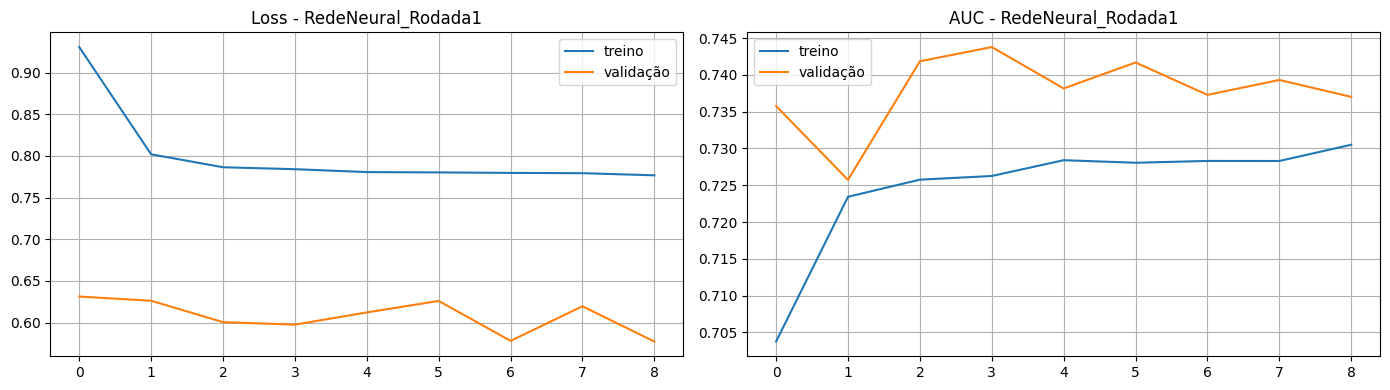

Melhor val_auc: 0.7438 (época 4)


In [104]:
# RODADA 1: treino -> teste1

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train_np,
    y_train_np,
    sw_train,
    test_size=0.1,
    stratify=y_train_np,
    random_state=42
)

modelo_RN = criar_modelo(X_train_np.shape[1])

historico = modelo_RN.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    sample_weight=sw_tr,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr]
)

plotar_curvas(historico, 'RedeNeural_Rodada1')



RedeNeural_Teste1
                  precision    recall  f1-score   support

Não abandona (0)       0.82      0.64      0.72       354
    Abandona (1)       0.64      0.82      0.72       277

        accuracy                           0.72       631
       macro avg       0.73      0.73      0.72       631
    weighted avg       0.74      0.72      0.72       631

ROC-AUC: 0.7997


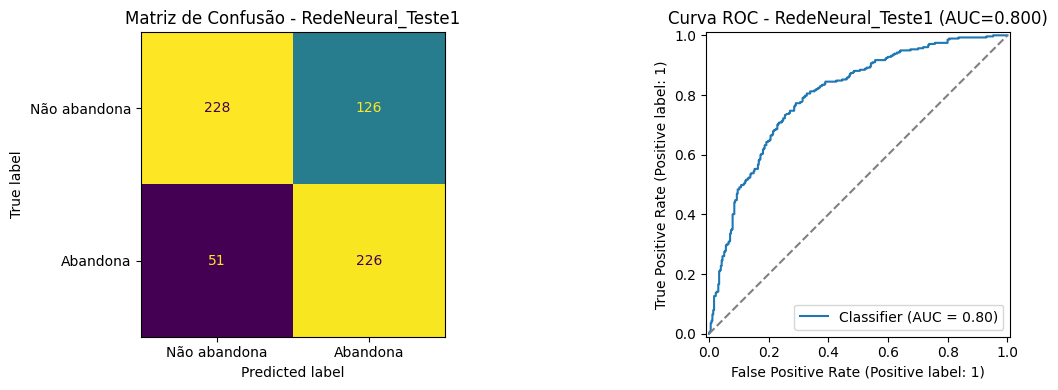

In [105]:
prob_test1 = modelo_RN.predict(X_test1_np, verbose=0).flatten()
pred_test1 = (prob_test1 >= 0.5).astype(int)
auc1 = avaliar('RedeNeural_Teste1', y_test1_np, pred_test1, prob_test1)

Epoch 1/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - accuracy: 0.6548 - auc: 0.7068 - loss: 0.9270 - val_accuracy: 0.7933 - val_auc: 0.7219 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 2/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - accuracy: 0.7066 - auc: 0.7250 - loss: 0.7999 - val_accuracy: 0.7522 - val_auc: 0.7396 - val_loss: 0.6114 - learning_rate: 0.0010
Epoch 3/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.7054 - auc: 0.7269 - loss: 0.7852 - val_accuracy: 0.6937 - val_auc: 0.7294 - val_loss: 0.6325 - learning_rate: 0.0010
Epoch 4/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.6986 - auc: 0.7228 - loss: 0.7885 - val_accuracy: 0.6471 - val_auc: 0.7116 - val_loss: 0.6837 - learning_rate: 0.0010
Epoch 5/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.7032 - auc: 0.7250 - loss: 0.7848 - val_accuracy: 0.6865 - val_auc: 0.7137 - val_loss: 0.6407 - learning_rate: 0.0010
Epoch 6/100
991/991 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy

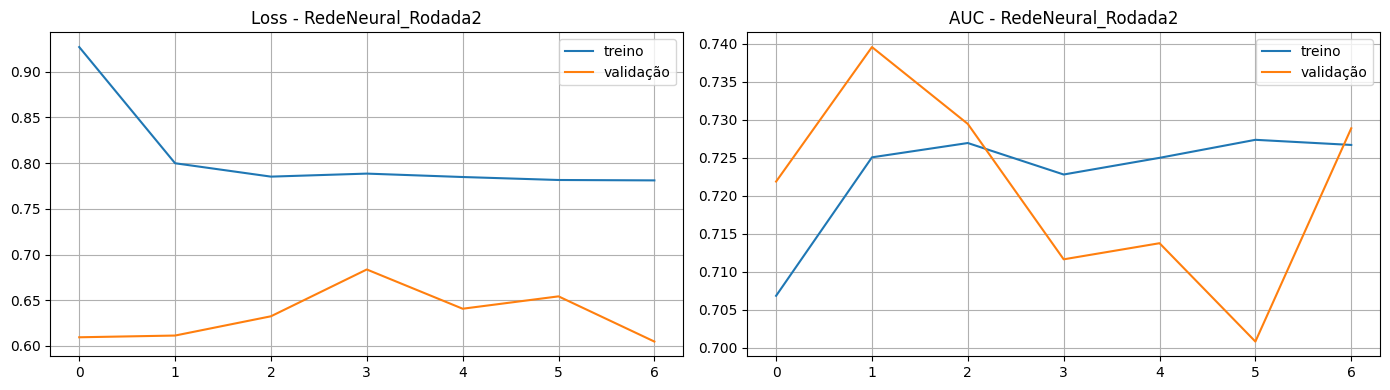

Melhor val_auc: 0.7396 (época 2)


In [106]:
# RODADA 2: treino + teste1 -> teste2

X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train2_np,
    y_train2_np,
    sw_train2,
    test_size=0.1,
    stratify=y_train2_np,
    random_state=42
)

modelo_RN2 = criar_modelo(X_train2_np.shape[1])

early_stop2 = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr2 = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.1,
    patience=8,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

historico2 = modelo_RN2.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    sample_weight=sw_tr,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

plotar_curvas(historico2, 'RedeNeural_Rodada2')


RedeNeural_Teste2
                  precision    recall  f1-score   support

Não abandona (0)       0.60      0.50      0.55       193
    Abandona (1)       0.80      0.85      0.82       438

        accuracy                           0.74       631
       macro avg       0.70      0.68      0.68       631
    weighted avg       0.74      0.74      0.74       631

ROC-AUC: 0.7675


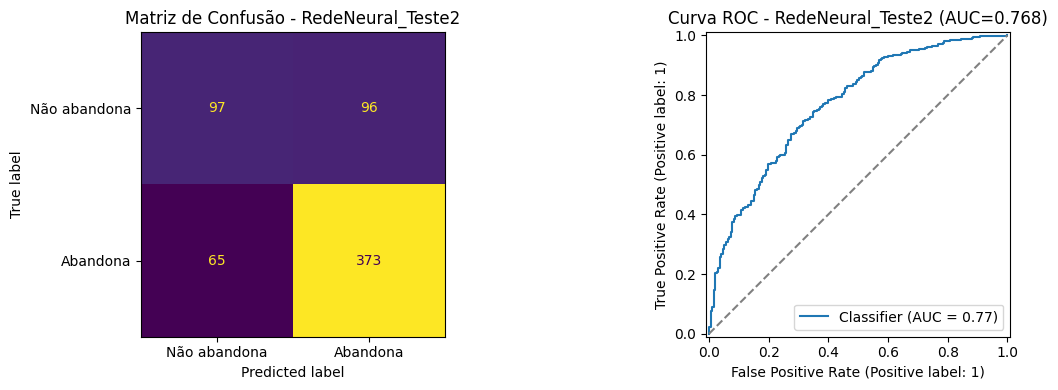

In [107]:
prob_test2 = modelo_RN2.predict(X_test2_np, verbose=0).flatten()
pred_test2 = (prob_test2 >= 0.5).astype(int)
auc2 = avaliar('RedeNeural_Teste2', y_test2_np, pred_test2, prob_test2)

Calculando Permutation Importance...
Concluído!


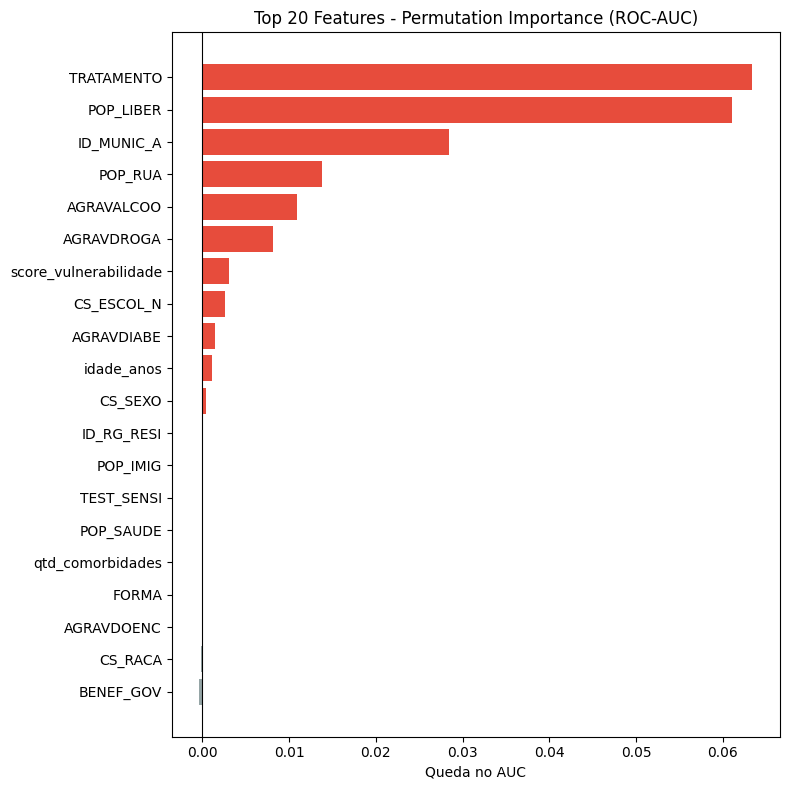


Top 10 features:
              feature  importancia
           TRATAMENTO       0.0634
            POP_LIBER       0.0611
           ID_MUNIC_A       0.0284
              POP_RUA       0.0138
           AGRAVALCOO       0.0109
           AGRAVDROGA       0.0082
score_vulnerabilidade       0.0030
           CS_ESCOL_N       0.0026
           AGRAVDIABE       0.0014
           idade_anos       0.0011


In [108]:
# Explicabilidade - Permutation Importance

class KerasWrapper:
    def __init__(self, model):
        self.model = model
        self._estimator_type = 'classifier'

    def fit(self, X, y):
        return self

    def predict(self, X):
        return self.model.predict(X, verbose=0)

    def score(self, X, y):
        preds = self.predict(X)
        return roc_auc_score(y, preds)

sample_size = min(631, len(X_test2_np))
idx = np.random.choice(len(X_test2_np), sample_size, replace=False)
X_sample = X_test2_np[idx]
y_sample = y_test2_np[idx]

print('Calculando Permutation Importance...')
result = permutation_importance(
    KerasWrapper(modelo_RN2),
    X_sample, y_sample,
    n_repeats=10,
    random_state=42,
    scoring=None
)
print('Concluído!')

df_imp = pd.DataFrame({
    'feature':     X_test2.columns.tolist(),
    'importancia': result.importances_mean
})
df_imp = df_imp.sort_values('importancia', ascending=False).reset_index(drop=True)

top20 = df_imp.head(20)
plt.figure(figsize=(8, 8))
plt.barh(top20['feature'][::-1], top20['importancia'][::-1],
         color=['#e74c3c' if v > 0 else '#95a5a6' for v in top20['importancia'][::-1]])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Permutation Importance (ROC-AUC)')
plt.xlabel('Queda no AUC')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/graficos/permutation_teste.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('\nTop 10 features:')
print(df_imp.head(10).to_string(index=False))
df_imp.to_csv(
    'permutation_importance.csv',
    index=False
)

In [109]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def resumo_metricas(nome, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
    'Modelo': nome,
    'Acurácia': accuracy_score(y_true, y_pred),
    'Precisão': precision_score(y_true, y_pred),
    'Recall': recall_score(y_true, y_pred),
    'F1': f1_score(y_true, y_pred),
    'ROC-AUC': roc_auc_score(y_true, y_prob)
}

pd.options.display.float_format = '{:.4f}'.format
resultados = pd.DataFrame([
    resumo_metricas('Rodada 1 - Teste1', y_test1_np, prob_test1),
    resumo_metricas('Rodada 2 - Teste2', y_test2_np, prob_test2),
])

resultados.to_csv('/content/drive/MyDrive/resultados_rede_neural.csv', index=False)
print('Resultados - Rede Neural')
print(resultados.to_string(index=False))

Resultados - Rede Neural
           Modelo  Acurácia  Precisão  Recall     F1  ROC-AUC
Rodada 1 - Teste1    0.7195    0.6420  0.8159 0.7186   0.7997
Rodada 2 - Teste2    0.7448    0.7953  0.8516 0.8225   0.7675


In [110]:
#Salvar modelos

modelo_RN2.save('/content/drive/MyDrive/modelo_RN.keras')
joblib.dump(top20, '/content/drive/MyDrive/top_features_RN.pkl')
print('modelo_RN.keras salvo!')

modelo_RN.keras salvo!
